In [1]:
from astropy.io import fits
import os
import numpy as np

MAG_cube = "../data/2018_08_25/cubes/MAG_24.fits"

# memmap + sin escalado automático: así NO se carga el cubo completo (~16 GB)
with fits.open(MAG_cube, memmap=True, do_not_scale_image_data=True) as hdul:
    hdul.info()

    hdr    = hdul[0].header
    bscale = hdr.get("BSCALE", 1.0)
    bzero  = hdr.get("BZERO", 0.0)
    blank  = hdr.get("BLANK", None)

    # Cube shape = (1920, 1024, 1024):
    raw = hdul[0].data[0]
    first_MAG = raw.astype(np.float64)

    if blank is not None:
        first_MAG[raw == blank] = np.nan

    first_MAG = first_MAG * bscale + bzero   # Gauss

print("first_MAG shape:", first_MAG.shape)
print(f"|B| range: {np.nanmin(np.abs(first_MAG)):.2f} – {np.nanmax(np.abs(first_MAG)):.2f} G")

Filename: ../data/2018_08_25/cubes/MAG_24.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      38   (1024, 1024, 1920)   int64   
first_MAG shape: (1024, 1024)
|B| range: 0.00 – 550.23 G


In [2]:
import os
import numpy as np
from astropy.io import fits

base_path = "../data/2018_08_25"

cropped_files = {
    "2.0-3.0 mHz":  "egress_pwr_02.0-03.0mHz_z0000km_cropped.fits",
    "3.0-4.0 mHz":  "egress_pwr_03.0-04.0mHz_z0000km_cropped.fits",
    "4.0-5.0 mHz":  "egress_pwr_04.0-05.0mHz_z0000km_cropped.fits",
    "5.0-6.0 mHz":  "egress_pwr_05.0-06.0mHz_z0000km_cropped.fits",
    "6.0-7.0 mHz":  "egress_pwr_06.0-07.0mHz_z0000km_cropped.fits",
    "7.0-8.0 mHz":  "egress_pwr_07.0-08.0mHz_z0000km_cropped.fits",
    "8.0-9.0 mHz":  "egress_pwr_08.0-09.0mHz_z0000km_cropped.fits",
    "9.0-10.0 mHz": "egress_pwr_09.0-10.0mHz_z0000km_cropped.fits",
    "10.0-11.0 mHz":"egress_pwr_10.0-11.0mHz_z0000km_cropped.fits",
}

cropped_frequencies = list(cropped_files.keys())
cropped_maps = []

for freq_band, filename in cropped_files.items():

    path = os.path.join(base_path, filename)

    with fits.open(path) as hdul:
        data_map = hdul[0].data.copy()

    cropped_maps.append(data_map)

    n_total = data_map.size
    n_nan   = np.isnan(data_map).sum()
    n_zero  = np.sum(data_map == 0)
    n_finite = np.isfinite(data_map).sum()

Total pixels:       1,048,576
Excluded zeros:     565,551
Valid pixels used:  483,025


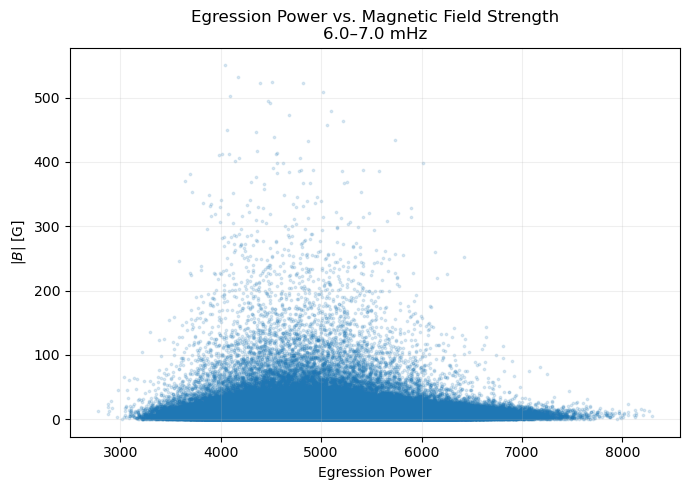

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Banda que queremos analizar
freq_idx = cropped_frequencies.index("6.0-7.0 mHz")
egression = cropped_maps[freq_idx]

# Campo magnético absoluto
B = np.abs(first_MAG)

# Máscara: solamente píxeles válidos en ambos mapas
valid = (
    np.isfinite(B) &
    np.isfinite(egression) &
    (egression != 0)
)

B_valid = B[valid]
P_valid = egression[valid]

print(f"Total pixels:       {egression.size:,}")
print(f"Excluded zeros:     {np.sum(egression == 0):,}")
print(f"Valid pixels used:  {np.sum(valid):,}")

# ------------------------------------------------------------
# Scatter plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    P_valid,
    B_valid,
    s=3,
    alpha=0.15
)

ax.set_ylabel(r"$|B|$ [G]")
ax.set_xlabel("Egression Power")
ax.set_title("Egression Power vs. Magnetic Field Strength\n6.0–7.0 mHz")

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

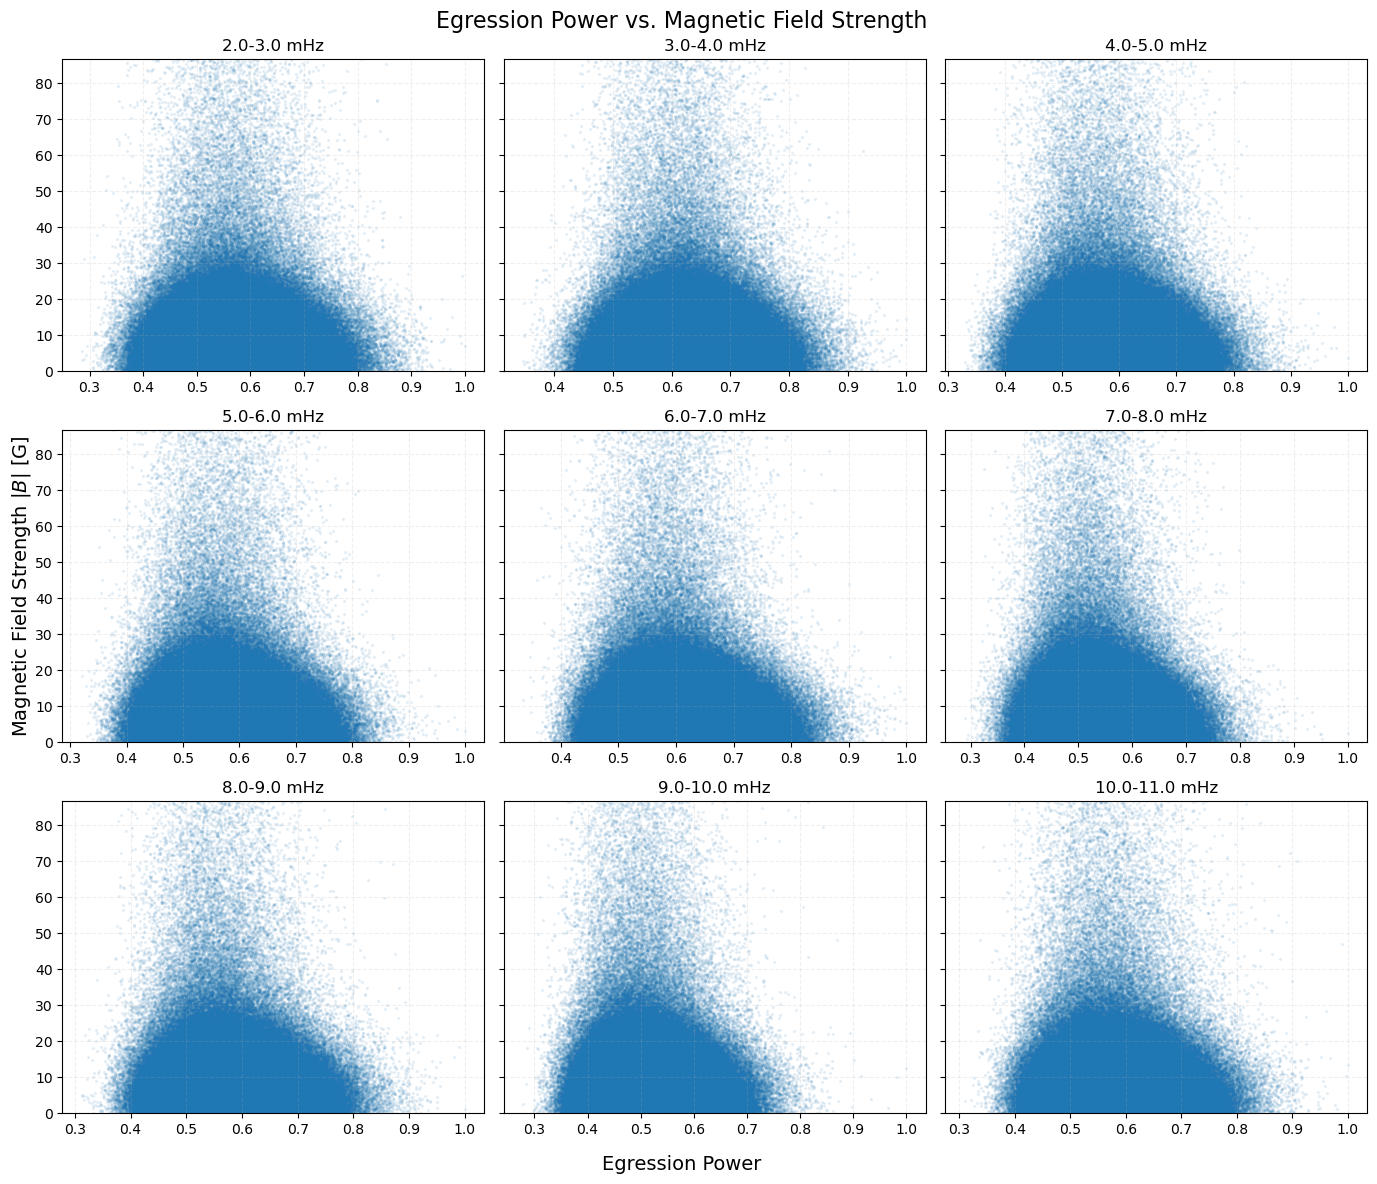

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# MAGNETIC FIELD
# ============================================================

B = np.abs(first_MAG)

# ============================================================
# 3x3 MOSAIC
# ============================================================

fig, axes = plt.subplots(
    3, 3,
    figsize=(14, 12),
    sharey=True
)

# Límite superior para visualizar B
B_max_plot = np.nanpercentile(B, 99.5)

axes = axes.flatten()

for ax, freq, egression in zip(
    axes,
    cropped_frequencies,
    cropped_maps
):
    
    # Píxeles válidos
    valid = (
        np.isfinite(B) &
        np.isfinite(egression) &
        (egression != 0)
    )

    B_valid = B[valid]
    P_valid = egression[valid]
    
    # Scatter
    ax.scatter(
        P_valid,
        B_valid,
        s=2,
        alpha=0.08,
        rasterized=True
    )

    # Límite del eje Y
    ax.set_ylim(0, B_max_plot)

    ax.set_title(freq)
    ax.grid(alpha=0.2, linestyle="--")

# Etiquetas generales
fig.supxlabel("Egression Power", fontsize=14)
fig.supylabel(r"Magnetic Field Strength $|B|$ [G]", fontsize=14)

fig.suptitle(
    "Egression Power vs. Magnetic Field Strength",
    fontsize=16
)

plt.tight_layout()
plt.show()

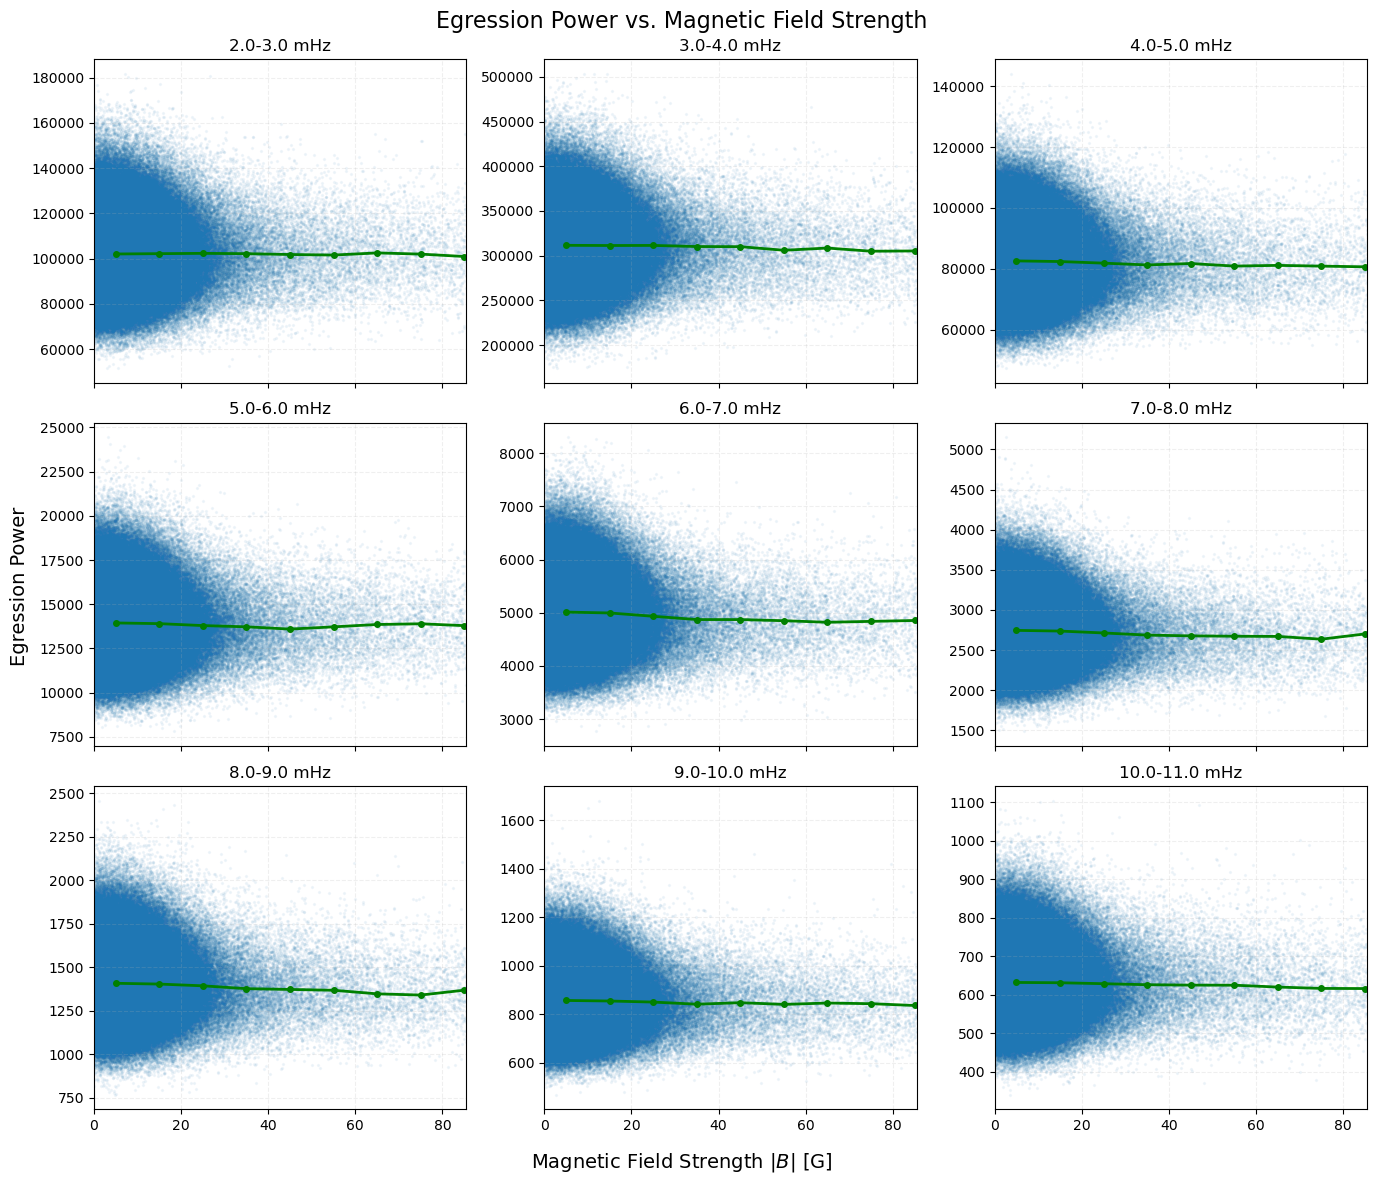

In [17]:
import numpy as np
import matplotlib.pyplot as plt

B = np.abs(first_MAG)

# ============================================================
# CONFIGURATION
# ============================================================

bin_width = 10  # G

fig, axes = plt.subplots(
    3, 3,
    figsize=(14, 12),
    sharex=True
)

axes = axes.flatten()


# ============================================================
# LOOP OVER FREQUENCY BANDS
# ============================================================

for ax, freq, egression in zip(
    axes,
    cropped_frequencies,
    cropped_maps
):

    # --------------------------------------------------------
    # 1. Valid pixels in BOTH maps
    # --------------------------------------------------------

    valid = (
        np.isfinite(B) &
        np.isfinite(egression) &
        (egression != 0)
    )

    B_valid = B[valid]
    P_valid = egression[valid]


    # --------------------------------------------------------
    # 2. Define magnetic-field bins
    # --------------------------------------------------------

    B_max = np.nanpercentile(B_valid, 99.5)

    B_bins = np.arange(
        0,
        B_max + bin_width,
        bin_width
    )

    B_centers = 0.5 * (
        B_bins[:-1] + B_bins[1:]
    )


    # --------------------------------------------------------
    # 3. Median egression power in each B bin
    # --------------------------------------------------------

    P_median = np.full(
        len(B_centers),
        np.nan
    )

    N_pixels = np.zeros(
        len(B_centers),
        dtype=int
    )


    for i in range(len(B_centers)):

        in_bin = (
            (B_valid >= B_bins[i]) &
            (B_valid < B_bins[i + 1])
        )

        N_pixels[i] = np.sum(in_bin)

        if N_pixels[i] > 0:

            P_median[i] = np.median(
                P_valid[in_bin]
            )


    # --------------------------------------------------------
    # 4. Pixel-by-pixel scatter
    # --------------------------------------------------------

    ax.scatter(
        B_valid,
        P_valid,
        s=2,
        alpha=0.05,
        rasterized=True
    )


    # --------------------------------------------------------
    # 5. Median egression power vs B
    # --------------------------------------------------------

    ax.plot(
        B_centers,
        P_median,
        "o-",
        color="green",
        linewidth=2,
        markersize=4,
        label="Median"
    )


    # --------------------------------------------------------
    # Appearance
    # --------------------------------------------------------

    ax.set_xlim(0, B_max)
    ax.set_title(freq)

    ax.grid(
        alpha=0.2,
        linestyle="--"
    )


# ============================================================
# GLOBAL LABELS
# ============================================================

fig.supxlabel(
    r"Magnetic Field Strength $|B|$ [G]",
    fontsize=14
)

fig.supylabel(
    "Egression Power",
    fontsize=14
)

fig.suptitle(
    "Egression Power vs. Magnetic Field Strength",
    fontsize=16
)

plt.tight_layout()
plt.show()

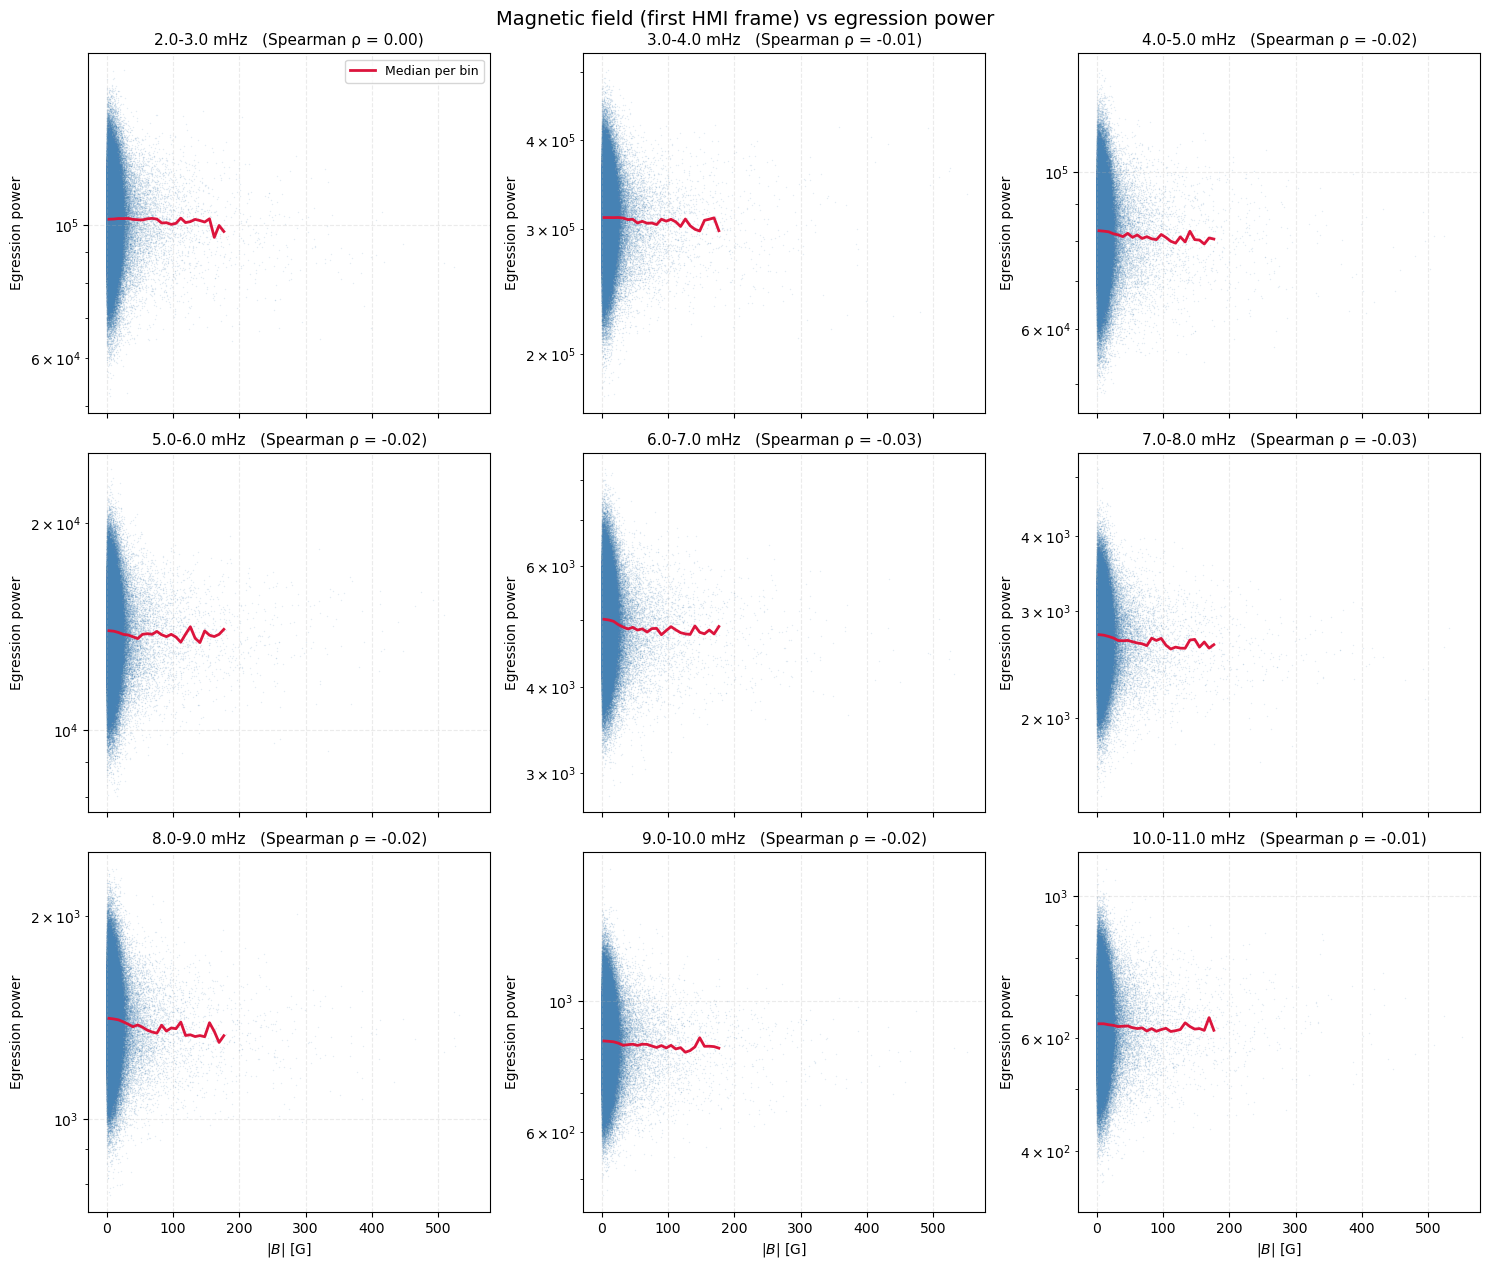

,Frequency,Valid pixels,Spearman rho
0,2.0-3.0 mHz,483025,0.004
1,3.0-4.0 mHz,483025,-0.006
2,4.0-5.0 mHz,483025,-0.018
3,5.0-6.0 mHz,483025,-0.018
4,6.0-7.0 mHz,483025,-0.033
5,7.0-8.0 mHz,483025,-0.027
6,8.0-9.0 mHz,483025,-0.024
7,9.0-10.0 mHz,483025,-0.016
8,10.0-11.0 mHz,483025,-0.011


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ============================================================
# SCATTER PLOT: |B| (primer frame) vs POTENCIA DE EGRESIÓN
# ============================================================

use_abs_B     = True    # True -> |B| ; False -> B con signo
log_power     = True    # eje y en escala logarítmica
n_bins        = 25      # bins de |B| para la curva de mediana
max_points    = 200_000 # puntos dibujados por panel (submuestreo aleatorio)
rng           = np.random.default_rng(0)

B_map = np.abs(first_MAG) if use_abs_B else first_MAG
B_label = r"$|B|$ [G]" if use_abs_B else r"$B$ [G]"

n_maps = len(cropped_maps)
n_cols = 3
n_rows = int(np.ceil(n_maps / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.3 * n_rows),
                         sharex=True, squeeze=False)
axes = axes.ravel()

summary = []

for i, (freq_band, P_map) in enumerate(zip(cropped_frequencies, cropped_maps)):

    if P_map.shape != B_map.shape:
        raise ValueError(f"{freq_band}: geometría {P_map.shape} ≠ magnetograma {B_map.shape}")

    # ---- Píxeles válidos: se ignoran los bordes recortados (NaN o 0) ----
    valid = (
        np.isfinite(P_map) & (P_map != 0) &
        np.isfinite(B_map)
    )
    if log_power:
        valid &= P_map > 0

    B = B_map[valid]
    P = P_map[valid]

    # ---- Correlación de Spearman (todos los píxeles válidos) ----
    rho, _ = spearmanr(B, P)

    # ---- Submuestreo solo para dibujar ----
    if B.size > max_points:
        idx = rng.choice(B.size, max_points, replace=False)
        B_plot, P_plot = B[idx], P[idx]
    else:
        B_plot, P_plot = B, P

    ax = axes[i]
    ax.scatter(B_plot, P_plot, s=1, alpha=0.15, color="steelblue",
               rasterized=True, linewidths=0)

    # ---- Mediana de la potencia por bin de |B| (tendencia) ----
    edges = np.linspace(np.nanpercentile(B, 0.5), np.nanpercentile(B, 99.9), n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    which = np.digitize(B, edges) - 1
    med = np.array([
        np.median(P[which == k]) if np.sum(which == k) >= 30 else np.nan
        for k in range(n_bins)
    ])
    ax.plot(centers, med, color="crimson", lw=2, label="Median per bin")

    if log_power:
        ax.set_yscale("log")

    ax.set_title(f"{freq_band}   (Spearman ρ = {rho:.2f})", fontsize=11)
    ax.set_ylabel("Egression power")
    ax.grid(alpha=0.25, linestyle="--")

    summary.append({"Frequency": freq_band, "Valid pixels": int(B.size), "Spearman rho": rho})

# Etiquetas del eje x solo en la última fila y paneles sobrantes ocultos
for ax in axes[n_maps:]:
    ax.set_visible(False)
for ax in axes[max(0, n_maps - n_cols):n_maps]:
    ax.set_xlabel(B_label)
axes[0].legend(loc="upper right", fontsize=9)

fig.suptitle("Magnetic field (first HMI frame) vs egression power", fontsize=14)
fig.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/Scatter_B_vs_egression.png", dpi=200, bbox_inches="tight")
plt.show()

import pandas as pd
display(pd.DataFrame(summary).round(3))